In [1]:
import geopandas as gpd
import numpy as np
import osmnx as ox
import matplotlib as plt
from sklearn.cluster import KMeans
from geopy.geocoders import Nominatim

In [2]:
# Download city boundaries
place = "Tampa, Florida, USA"
boundary = ox.geocode_to_gdf(place)

In [3]:
# Download the road map data
graph = ox.graph_from_place(place, network_type="drive")

# Project the graph to local UTM -> avoiding distortion
graph_proj = ox.project_graph(graph)

# Matching boundary crs to road data
boundary_proj = boundary.to_crs(graph_proj.graph['crs'])

In [4]:
# Initialize the geolocator
geolocator = Nominatim(user_agent="tampa_logistics_app")

# Provide the address (random address at Tampa port)
address = "1101 Channelside Dr, Tampa, FL 33602"

# Get the coordinates
location = geolocator.geocode(address)

if location:
    warehouse_lat = location.latitude
    warehouse_long = location.longitude
    print(f"Latitude: {location.latitude}, Longitude: {location.longitude}")
else:
    print("Address not found!")

Latitude: 27.951531, Longitude: -82.445453


In [5]:
# Create a GDF for the warehouse
warehouse_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([warehouse_long], [warehouse_lat]), 
    crs="EPSG:4326"
).to_crs(graph_proj.graph['crs'])

# Snap the warehouse to the nearest road node too!
warehouse_node = ox.distance.nearest_nodes(graph_proj, [warehouse_long], [warehouse_lat])[0]

In [6]:
# Generating 300 random (x,y) points in inside Tampa boundaries
min_x, min_y, max_x, max_y = boundary.total_bounds

points = []

while len(points) < 300:
    x = np.random.uniform(min_x, max_x)
    y = np.random.uniform(min_y, max_y)
    p = gpd.points_from_xy([x],[y])[0]

    if p.within(boundary.geometry.iloc[0]):
        points.append(p)


<Axes: >

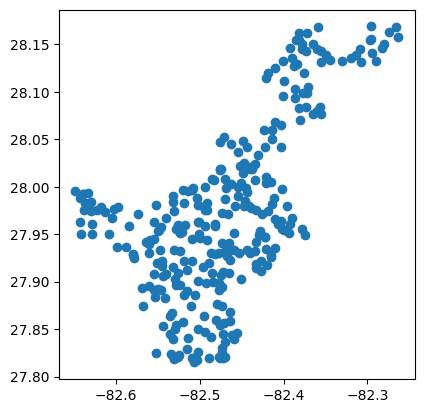

In [7]:
# Creating a GDF 
delivery_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")
delivery_gdf.plot()

In [8]:
# Save raw generated data
delivery_gdf.to_file("../data/raw/delivery_points_raw.geojson"
                     , driver="GeoJSON")
# Save the road network
ox.save_graphml(graph_proj, filepath="../data/processed/tampa_road_network.graphml")

In [9]:
# converting to meters for accurate distance math
delivery_gdf_proj = delivery_gdf.to_crs(graph_proj.graph['crs'])

# finding nearest roads Ids (nodes)
nodes = ox.distance.nearest_nodes(
    graph_proj,
    delivery_gdf_proj.geometry.x,
    delivery_gdf_proj.geometry.y)

In [10]:
# create the snapped points IDs -> POINT
snapped_points = [gpd.points_from_xy([graph_proj.nodes[n]['x']],
                                     [graph_proj.nodes[n]['y']])[0]
                for n in nodes]
# create a new GDF for the final locations
snapped_gdf = gpd.GeoDataFrame(geometry=snapped_points, crs=graph_proj.graph['crs'])

In [11]:
# Save processed / cleaned data (road snapped delivery locations)
snapped_gdf.to_file("../data/processed/delivery_points_snapped.gpkg", driver="GPKG")

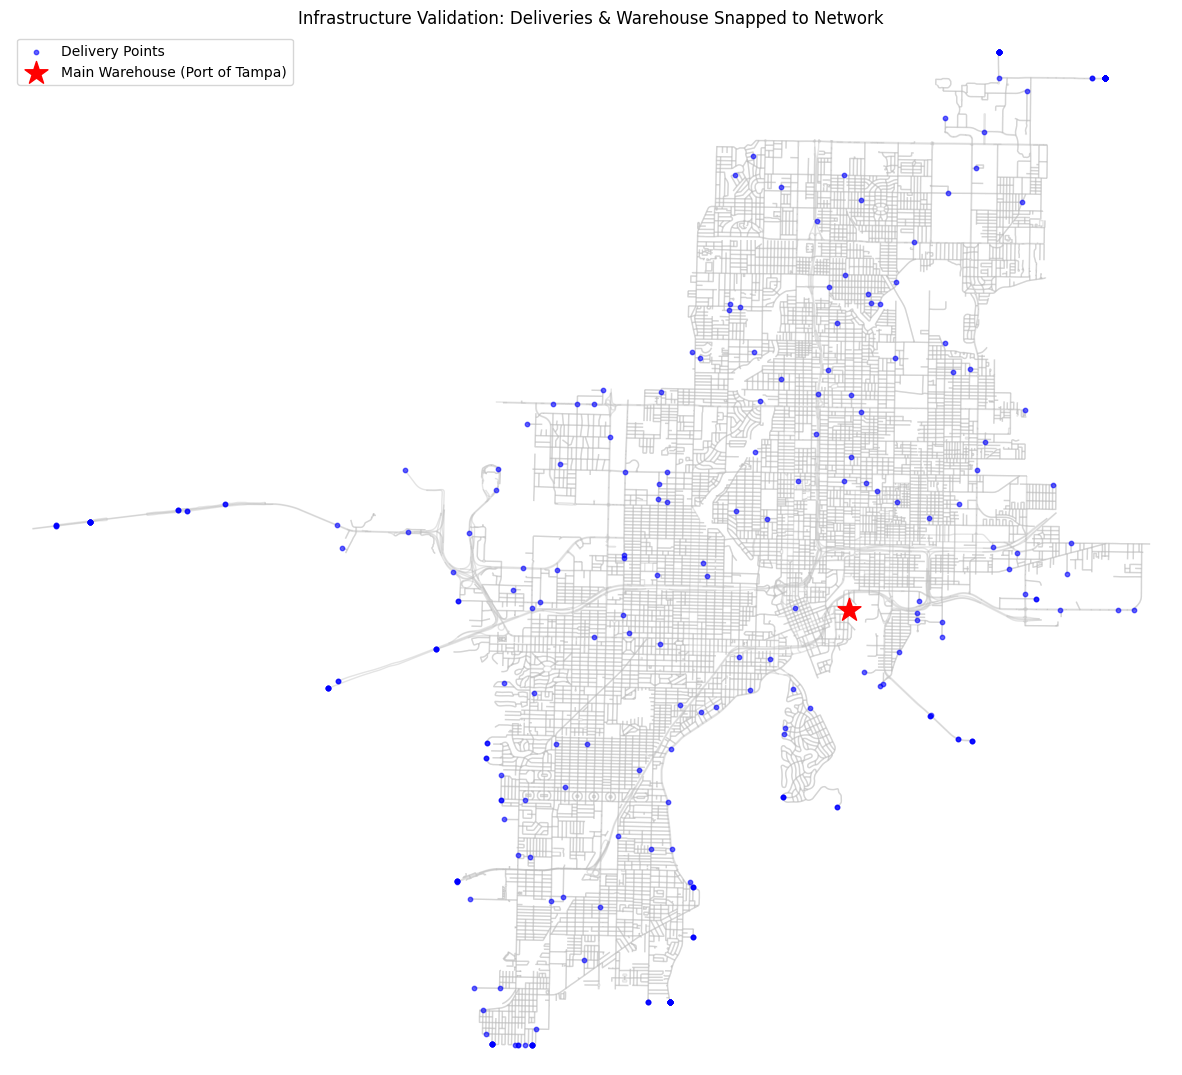

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 15))

# 1. Plot the road network
ox.plot_graph(graph_proj, ax=ax, show=False, close=False, edge_color='#bcbcbc', edge_alpha=0.4, node_size=0)

# 2. Plot the 300 delivery points (Blue)
snapped_gdf.plot(ax=ax, color='blue', markersize=10, alpha=0.6, label='Delivery Points')

# 3. Plot the Warehouse (Red Star)
# We pull the coordinates directly from the warehouse_gdf we created
warehouse_gdf.plot(ax=ax, color='red', marker='*', markersize=300, label='Main Warehouse (Port of Tampa)')

plt.legend()
plt.title("Infrastructure Validation: Deliveries & Warehouse Snapped to Network")

# save a copy
plt.savefig('../reports/figures/infrastructure_validation.png', dpi=300, bbox_inches='tight')
plt.show()

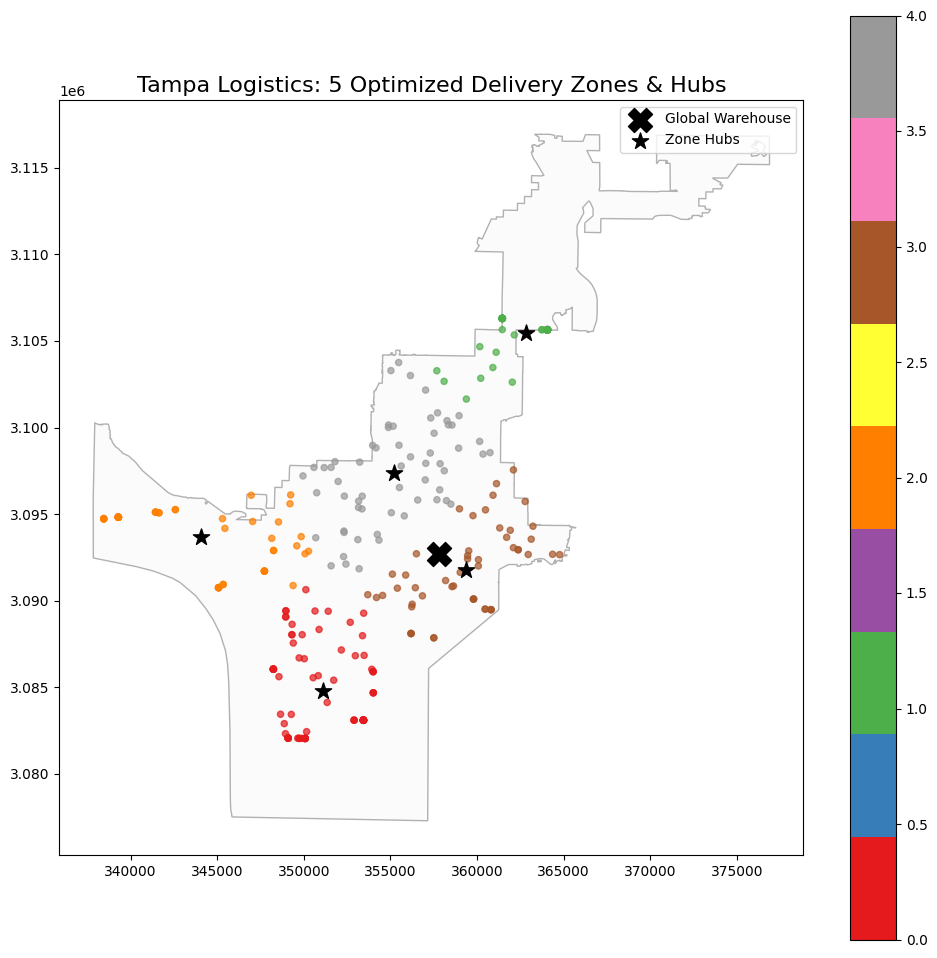

In [13]:
# Prepare coordinates (must be in meters)
coords = np.array(list(zip(snapped_gdf.geometry.x, snapped_gdf.geometry.y)))

# 2. Define 5 delivery zones (for 5 drivers)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
snapped_gdf['zone_id'] = kmeans.fit_predict(coords)

# 3. Calculate Centroids (the center point of each new zone)
centroids = snapped_gdf.groupby('zone_id').geometry.apply(
    lambda x: gpd.points_from_xy([x.x.mean()], [x.y.mean()])[0]
)
centroids_gdf = gpd.GeoDataFrame(geometry=centroids, crs=graph_proj.graph['crs'])

snapped_gdf.to_file("../data/processed/delivery_data_final_with_zones.gpkg", driver="GPKG")

# 4. Final Visualization
fig, ax = plt.subplots(figsize=(12, 12))
boundary_proj.plot(ax=ax, color='#f9f9f9', edgecolor='#666666', alpha=0.5)

# Plot Delivery Points by Zone
snapped_gdf.plot(ax=ax, column='zone_id', cmap='Set1', markersize=20, alpha=0.7, legend=True)

# Plot Warehouse (The Source)
warehouse_gdf.plot(ax=ax, color='black', marker='X', markersize=300, label='Global Warehouse')

# Plot Zone Centroids (The Local Hubs)
centroids_gdf.plot(ax=ax, color='black', marker='*', markersize=150, label='Zone Hubs')

plt.title("Tampa Logistics: 5 Optimized Delivery Zones & Hubs", fontsize=16)
plt.legend()
plt.savefig('../reports/figures/delivery_zones_kmeans.png', dpi=300)
plt.show()

In [15]:
import networkx as nx
import math

# 1. Filter for Zone 0 (Red)
zone_0_gdf = snapped_gdf[snapped_gdf['zone_id'] == 0].copy()

# 2. Get Node IDs
delivery_nodes = [ox.distance.nearest_nodes(graph_proj, [pt.x], [pt.y])[0] for pt in zone_0_gdf.geometry]
all_route_nodes = [warehouse_node] + delivery_nodes

# --- THE FAST TSP HEURISTIC ---

# 3. Extract just the X/Y coordinates for our route nodes
node_coords = {node: (graph_proj.nodes[node]['x'], graph_proj.nodes[node]['y']) for node in all_route_nodes}

# 4. Build a tiny, complete graph using straight-line math
G_tsp = nx.Graph()
for i in all_route_nodes:
    for j in all_route_nodes:
        if i != j:
            dist = math.dist(node_coords[i], node_coords[j])
            G_tsp.add_edge(i, j, weight=dist)

# 5. Solve TSP on the tiny graph (Should take less than 1 second)
tsp_order = nx.approximation.traveling_salesman_problem(G_tsp, weight='weight', cycle=True)

# 6. Snap the sequence back to the real road network
final_path = []
for i in range(len(tsp_order) - 1):
    path_segment = ox.shortest_path(graph_proj, tsp_order[i], tsp_order[i+1], weight='length')
    if path_segment:
        # Extend the list, but drop the last node so we don't duplicate connection points
        final_path.extend(path_segment[:-1]) 

print(f"Boom! Route optimized. Total street segments in path: {len(final_path)}")

Boom! Route optimized. Total street segments in path: 432


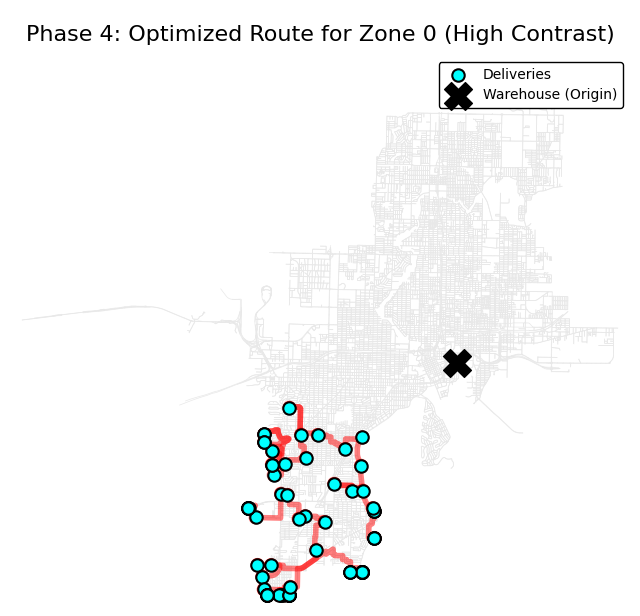

In [20]:
import matplotlib.pyplot as plt

# 1. Plot the routes with a WHITE background and faint streets
fig, ax = ox.plot_graph_routes(
    graph_proj, 
    route_segments, 
    route_colors='#FF0000',      # Bright pure red for the driving path
    route_linewidths=4,          # Thicker lines
    node_size=0, 
    bgcolor='#FFFFFF',           # Force a crisp white background
    edge_color='#E8E8E8',        # Make the background streets very faint grey
    edge_linewidth=0.5,
    show=False, 
    close=False
)

# 2. Plot deliveries: Bright Cyan with a sharp black border to make them pop
zone_0_gdf.plot(
    ax=ax, 
    color='#00FFFF',             # Neon Cyan
    edgecolor='black',           # Black border prevents blending
    linewidth=1.5, 
    markersize=80,               # Make the dots bigger
    label='Deliveries', 
    zorder=5                     # Ensure dots sit ON TOP of the red line
)

# 3. Plot the Warehouse
warehouse_gdf.plot(
    ax=ax, 
    color='black', 
    marker='X', 
    markersize=400, 
    label='Warehouse (Origin)', 
    zorder=6
)

# 4. Final Formatting
plt.title("Phase 4: Optimized Route for Zone 0 (High Contrast)", fontsize=16, pad=10)
plt.legend(facecolor='white', framealpha=1, edgecolor='black', loc='upper right')
plt.savefig('../reports/figures/zone_0_route_clean.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Calculate the total distance in meters
total_meters = 0

# We use the tsp_order from our previous fast-routing step
for i in range(len(tsp_order) - 1):
    try:
        # Get the length of the shortest path between each stop
        segment_length = nx.shortest_path_length(graph_proj, tsp_order[i], tsp_order[i+1], weight='length')
        total_meters += segment_length
    except nx.NetworkXNoPath:
        # If a segment fails to connect, we skip adding it to prevent crashes
        continue

# Convert meters to miles
total_miles = total_meters * 0.000621371

# Estimate drive time (assuming an average urban delivery speed of 25 mph)
estimated_hours = total_miles / 25.0
estimated_minutes = estimated_hours * 60

print("--- Zone 0 Route Metrics ---")
print(f"Total Distance: {total_miles:.2f} miles")
print(f"Estimated Driving Time: {estimated_minutes:.0f} minutes (excluding drop-off time)")

--- Zone 0 Route Metrics ---
Total Distance: 33.49 miles
Estimated Driving Time: 80 minutes (excluding drop-off time)


In [23]:
import networkx as nx
import math

print("🚀 Initiating Fleet-Wide Route Optimization...\n")

total_company_miles = 0
fleet_metrics = {}

# Loop through all 5 drivers (Zones 0 through 4)
for zone_id in range(5):
    # 1. Filter data for the specific driver
    zone_gdf = snapped_gdf[snapped_gdf['zone_id'] == zone_id].copy()
    
    # 2. Map coordinates to the road network
    delivery_nodes = [ox.distance.nearest_nodes(graph_proj, [pt.x], [pt.y])[0] for pt in zone_gdf.geometry]
    route_nodes = [warehouse_node] + delivery_nodes
    
    # 3. Calculate the fastest sequence of stops (The Heuristic)
    node_coords = {node: (graph_proj.nodes[node]['x'], graph_proj.nodes[node]['y']) for node in route_nodes}
    G_tsp = nx.Graph()
    for i in route_nodes:
        for j in route_nodes:
            if i != j:
                G_tsp.add_edge(i, j, weight=math.dist(node_coords[i], node_coords[j]))
                
    tsp_order = nx.approximation.traveling_salesman_problem(G_tsp, weight='weight', cycle=True)
    
    # 4. Calculate actual street driving distance
    zone_meters = 0
    for i in range(len(tsp_order) - 1):
        try:
            zone_meters += nx.shortest_path_length(graph_proj, tsp_order[i], tsp_order[i+1], weight='length')
        except nx.NetworkXNoPath:
            continue # Skip broken connections silently
            
    # 5. Convert to business metrics
    zone_miles = zone_meters * 0.000621371
    total_company_miles += zone_miles
    fleet_metrics[f"Driver {zone_id}"] = zone_miles
    
    print(f"✅ Driver {zone_id} Route Complete: {zone_miles:.2f} miles")

# --- Final Executive Summary ---
print("\n--- 📊 FINAL FLEET METRICS ---")
print(f"Total Fleet Driving Distance: {total_company_miles:.2f} miles")

# Assuming a heavy delivery truck gets ~10 mpg and diesel is $5.00/gal
fuel_cost = (total_company_miles / 10.0) * 5.00
print(f"Estimated Daily Fuel Cost: ${fuel_cost:.2f}")

🚀 Initiating Fleet-Wide Route Optimization...

✅ Driver 0 Route Complete: 33.49 miles
✅ Driver 1 Route Complete: 50.98 miles
✅ Driver 2 Route Complete: 43.22 miles
✅ Driver 3 Route Complete: 62.83 miles
✅ Driver 4 Route Complete: 68.70 miles

--- 📊 FINAL FLEET METRICS ---
Total Fleet Driving Distance: 259.21 miles
Estimated Daily Fuel Cost: $129.61
